# 3.3 Radiative transfer

In this notebook we want to create a radiative transfer image of our planetesimal formation simulation. This can be easily done using DustPyLib and RADMC-3D or purely with the slab model of DustPyLib.

In the first step we want to load the final snapshot of our simulation.

In [1]:
from pathlib import Path

In [2]:
datadir = Path("3.2_substructure_planetesimal_formation")
files = list(datadir.glob("*.hdf5"))
files.sort()

In [3]:
datafile = files[-1]

In [4]:
from simframe import writers

In [5]:
wrtr = writers.hdf5writer()
data = wrtr.read.output(datafile.as_posix())

## RADMC-3D

In the next step we create a RADMC-3D model using DustPyLib.

In [6]:
from dustpylib.radtrans import radmc3d

In [7]:
radtrans = radmc3d.Model(data)

This object stores now all the information to create the RADMC-3D input files. But we can still customize them to our needs.

### Azimuthal grid

In this step we want to turn off the azimuthal grid, i.e. we only want to use a axisymmetric model. For this we have to tell the object to only use two grid cell interfaces.

In [8]:
import numpy as np

In [9]:
radtrans.phii_grid = np.array([0., 2.*np.pi])

### Particle sizes

By default DustPyLib would create 16 particle species for RADMC-3D between the smallest and the largest size in our simulation. It can, however, happen that our dust particles didn't grow to the upper end of the mass grid. To avoid empty particle species in the RADMC-3D model, we should inspect our simulation to see what the largest particles sizes actually are. to do this, we check which is the largest mass bin that is above the floor value.

In [10]:
irmax = (data.dust.Sigma>data.dust.SigmaFloor).argmin(-1).argmax()
amax = data.dust.a[irmax, np.max((data.dust.Sigma>data.dust.SigmaFloor).argmin(-1))+1]

We can then set the interfaces of the particle size bins.

In [11]:
radtrans.ai_grid = np.geomspace(data.dust.a.min(), amax, 17)

### RADMC-3D options

The RADMC-3D input file `radmc3d.inp` contains additional options for the RADMC-3D run. These can be accessed with

In [12]:
radtrans.radmc3d_options

{'modified_random_walk': 1, 'iranfreqmode': 1, 'istar_sphere': 1}

Here we want to set the number of photons to be used in our runs

In [13]:
radtrans.radmc3d_options["nphot"] = 1_000_000
radtrans.radmc3d_options["nphot_scat"] = 100_000
radtrans.radmc3d_options["nphot_spec"] = 10_000

Additionally we set some options to reduce the runtime for optically thick runs and reduce the number of scattering angles.

In [14]:
radtrans.radmc3d_options["mc_scat_maxtauabs"] = 5.
radtrans.radmc3d_options["dust_2daniso_nphi"] = 60

Finally we tell DustPyLib in which directory the RADMC-3D files should be stored.

In [15]:
radtrans.datadir = "3.3_radmc3d"

We can now create the RADMC-3D files.

In [16]:
radtrans.write_files()

Writing 3.3_radmc3d/radmc3d.inp.....done.
Writing 3.3_radmc3d/stars.inp.....done.
Writing 3.3_radmc3d/wavelength_micron.inp.....done.
Writing 3.3_radmc3d/amr_grid.inp.....done.
Writing 3.3_radmc3d/dust_density.inp.....done.
Writing 3.3_radmc3d/dust_temperature.dat.....done.
Writing 3.3_radmc3d/dustopac.inp.....done.

Computing opacities...
Using dsharp_opac. Please cite Birnstiel et al. (2018).
Using DSHARP mix. Please cite Birnstiel et al. (2018).
Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642    

/home/s/Sebastian.Stammler/.pixi/envs/user/base/.pixi/envs/default/lib/python3.14/site-packages/dsharp_opac/dsharp_opac.py:2887: RuntimeWarning: invalid value encountered in scalar divide
  g[grain, i] = -2 * np.pi * \



Writing 3.3_radmc3d/dustkapscatmat_00.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_01.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_02.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_03.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_04.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_05.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_06.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_07.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_08.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_09.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_10.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_11.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_12.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_13.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_14.inp.....done.
Writing 3.3_radmc3d/dustkapscatmat_15.inp.....done.

Writing 3.3_radmc3d/metadata.npz.....done.


### Inspecting the model

We can also use DustPyLib to read an existing RADMC-3D model to inspect the densities.

In [17]:
model = radmc3d.read_model(datadir=radtrans.datadir)

We can use this function to plot the densities and temperature.

In [18]:
from dustpy import constants as c
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150.

In [19]:
def plot_model(model, spec=-1):
    """
    Function plots the RADMC-3D model.

    Parameters
    ----------
    model : namespace
        The RADMC-3D model data
    spec : integer, optional, default : -1
        Particle species to be plotted. If -1, the total
        dust densities are plotted.
    """
    width = 6.
    height = width/1.3

    if spec==-1:
        rho = np.maximum(np.hstack((model.rho[:, :1, 0, :].sum(-1), model.rho[:, :, 0, :].sum(-1))), 1.e-100)
        T = np.hstack((model.T[:, :1, :, 0], model.T[:, :, :, 0])).mean(-1)
        a_rho = "total"
        a_T = "$a$ = {:.2e} cm".format(model.grid.a[0])
    else:
        rho = np.maximum(np.hstack((model.rho[:, :1, 0, spec], model.rho[:, :, 0, spec])), 1.e-100)
        T = np.hstack((model.T[:, :1, :, spec], model.T[:, :, :, spec])).mean(-1)
        a_rho = "$a$ = {:.2e} cm".format(model.grid.a[spec])
        a_T = "$a$ = {:.2e} cm".format(model.grid.a[spec])

    rho = np.hstack((rho, np.flip(rho[:, 1:, ...], 1)))
    T = np.hstack((T, np.flip(T[:, 1:, ...], 1)))

    theta = np.hstack((model.grid.theta[0]-(model.grid.theta[1]-model.grid.theta[0]), model.grid.theta))
    theta = np.hstack((theta, theta[1:]+np.pi))
    lev_rho_max = np.ceil(np.log10(rho.max()))
    levels_rho = np.arange(lev_rho_max-6, lev_rho_max+1, 1.)

    fig, ax = plt.subplots(ncols=2, figsize=(2*width, height), subplot_kw={"projection": "polar"})

    p0 = ax[0].contourf(theta, model.grid.r/c.au, np.log10(rho), levels=levels_rho, extend="both", cmap="viridis")
    ax[0].contourf(-theta, model.grid.r/c.au, np.log10(rho), levels=levels_rho, extend="both", cmap="viridis")
    ax[0].set_theta_zero_location("N")
    ax[0].set_rlim(0)
    ax[0].set_rscale("symlog")
    ax[0].set_rgrids([1., 10., 100.], angle=-45)
    ax[0].tick_params(axis='y', colors='white')
    ax[0].set_xticks([])
    ax[0].plot(0., 0., "*", color="C3", markeredgewidth=0, markersize=12)
    cbar0 = plt.colorbar(p0)
    cbar0.set_ticks(cbar0.get_ticks())
    cbar0.set_ticklabels(["$10^{{{:d}}}$".format(int(t)) for t in cbar0.get_ticks()])
    cbar0.set_label(r"$\rho_\mathrm{dust}$ [g/cm³]")
    ax[0].set_title("Dust density, {}".format(a_rho))

    p1 = ax[1].contourf(theta, model.grid.r/c.au, T, extend="both", cmap="coolwarm")
    ax[1].contourf(-theta, model.grid.r/c.au, T, extend="both", cmap="coolwarm")
    ax[1].set_theta_zero_location("N")
    ax[1].set_rlim(0)
    ax[1].set_rscale("symlog")
    ax[1].set_rgrids([1., 10., 100.], angle=-45)
    ax[1].tick_params(axis='y', colors='black')
    ax[1].set_xticks([])
    ax[1].plot(0., 0., "*", color="C3", markeredgewidth=0, markersize=12)
    cbar1 = plt.colorbar(p1)
    cbar1.set_ticks(cbar1.get_ticks())
    cbar1.set_label(r"$T$ [K]")
    ax[1].set_title("Dust temperature, {}".format(a_T))

    fig.tight_layout()

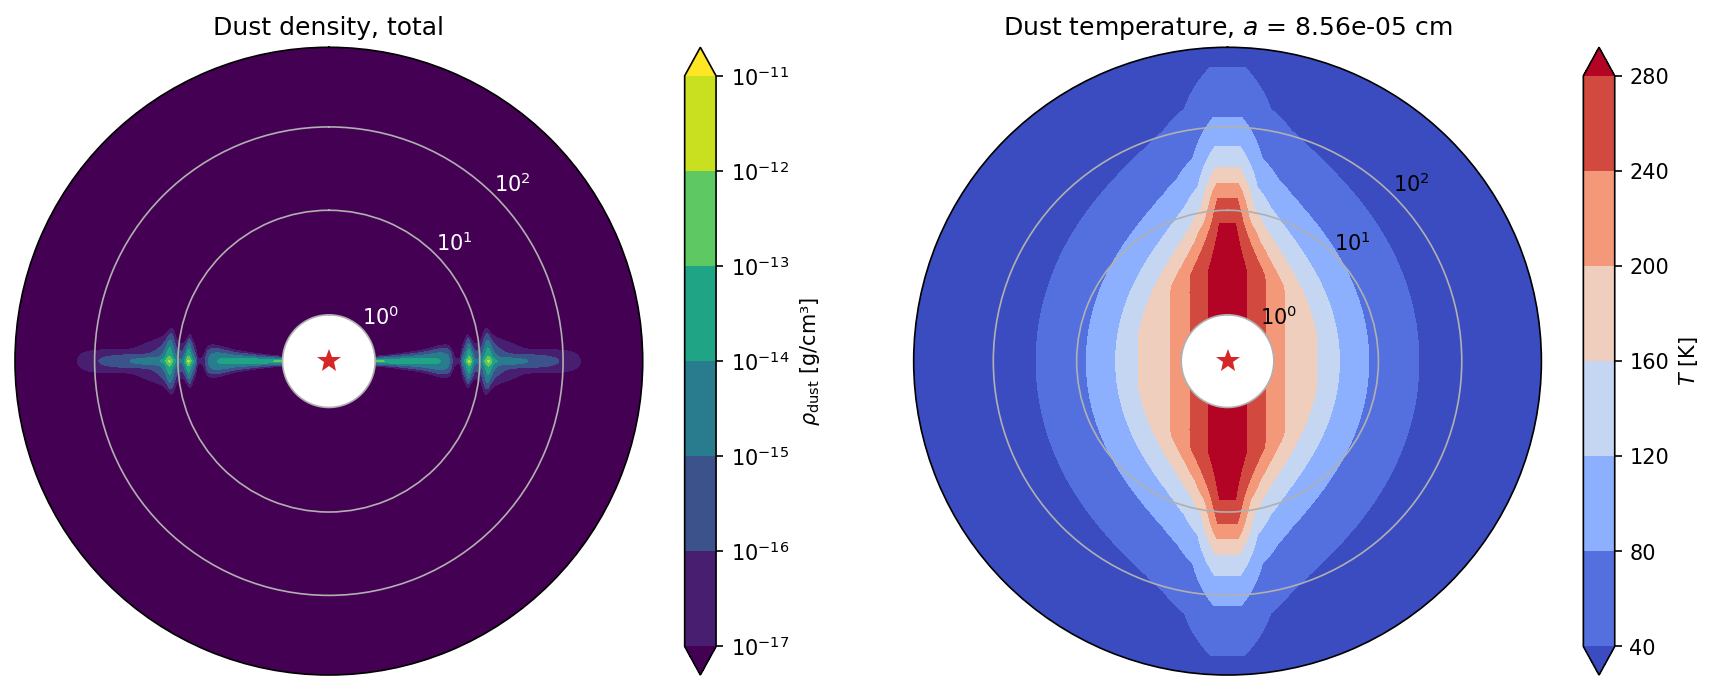

In [20]:
plot_model(model)

It can be seen that the temperatures are taken from DustPy and not computed with RADMC-3D. To do so we need to start the thermal run.

In [21]:
! cd 3.3_radmc3d/ && radmc3d mctherm setthreads 8 > mctherm.out

If you do not want to run the thermal Monte Carlo run on your own you can use this file instead.

In [22]:
! cp 3.3_radmc3d/radmc3d_dust_temperature.dat 3.3_radmc3d/dust_temperature.dat

We can now plot the simulation again and see the differences in temperature.

In [23]:
model_mc = radmc3d.read_model(datadir=radtrans.datadir)

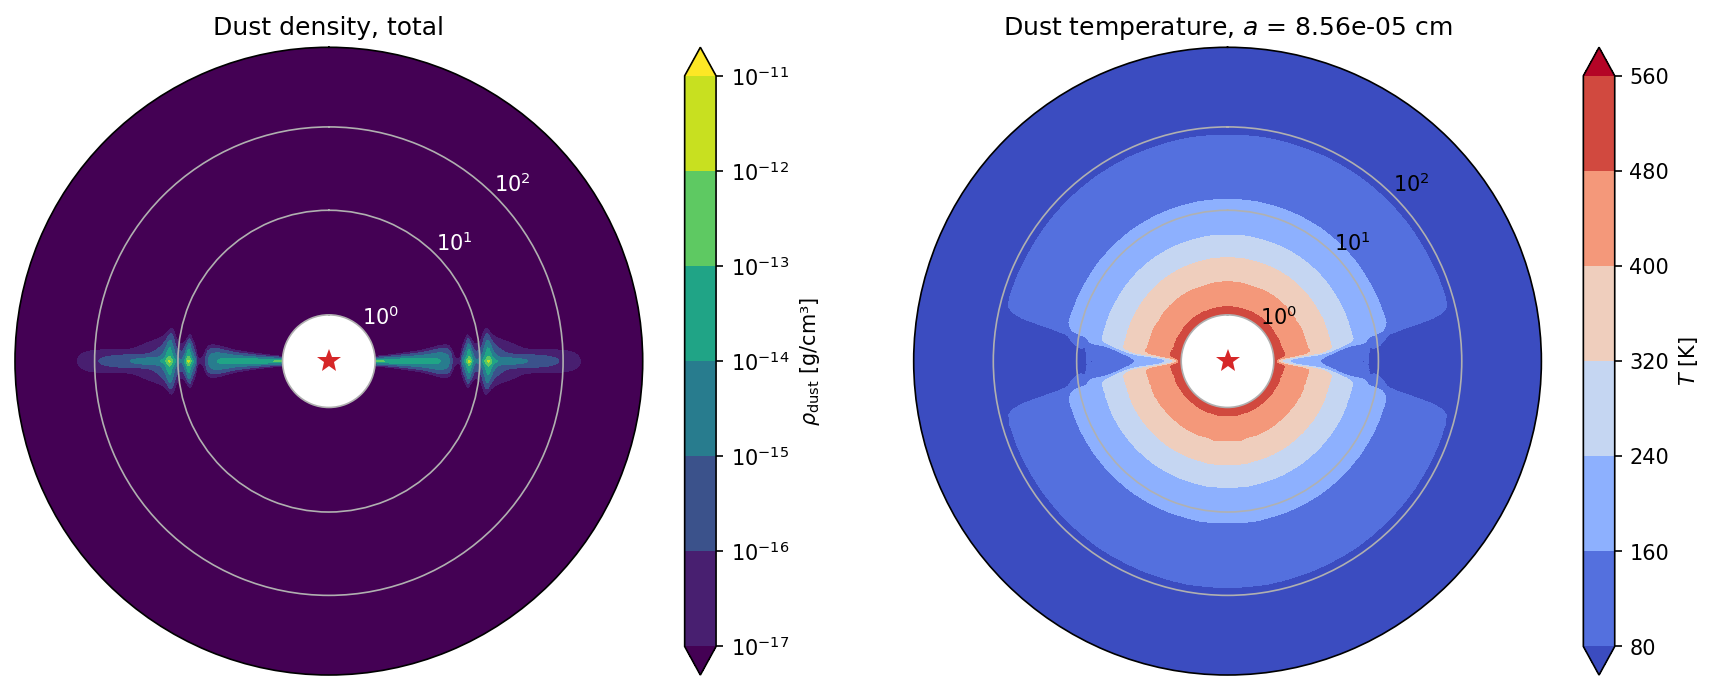

In [24]:
plot_model(model_mc)

### Comparison to DustPy

We can now compare midplane temperature profile that DustPy is assuming with the output of RADMC-3D.

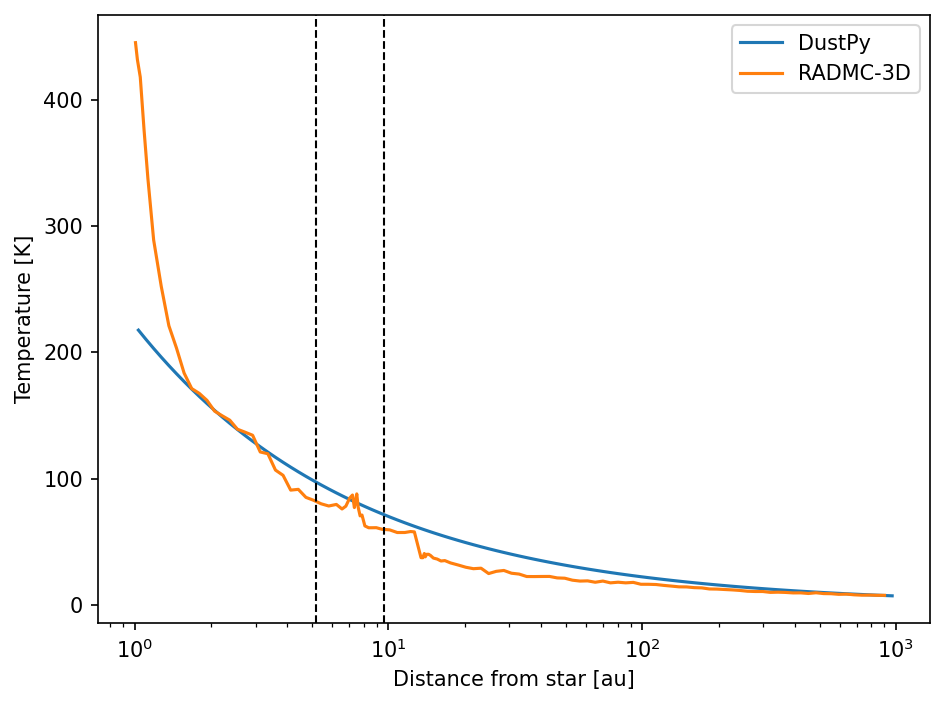

In [25]:
Ntheta = len(model_mc.grid.theta)
fig, ax = plt.subplots()
ax.plot(data.grid.r/c.au, data.gas.T, label="DustPy")
ax.plot(model_mc.grid.r/c.au, model_mc.T[:, Ntheta//2, 0, :].mean(-1), label="RADMC-3D")
for name, planet in data.planets:
    ax.axvline(planet.a/c.au, lw=1, color="black", ls="--")
ax.set(
    xscale="log", xlabel="Distance from star [au]",
    ylabel="Temperature [K]",
)
ax.legend()
fig.set_layout_engine("tight")

### Radio image

With these preparations we can now create a radio image at $1.3\,\mathrm{mm}$.

In [26]:
! cd 3.3_radmc3d/ && radmc3d image lambda 1300 sizeau 100 npixx 512 npixy 512 setthreads 8 > mcimage.out

If you do not want to run RADMC-3D on your own the image file is already in the repository.

We can now load the image and plot the intensities.

In [27]:
image = radmc3d.read_image(Path(radtrans.datadir).joinpath("image.out"))

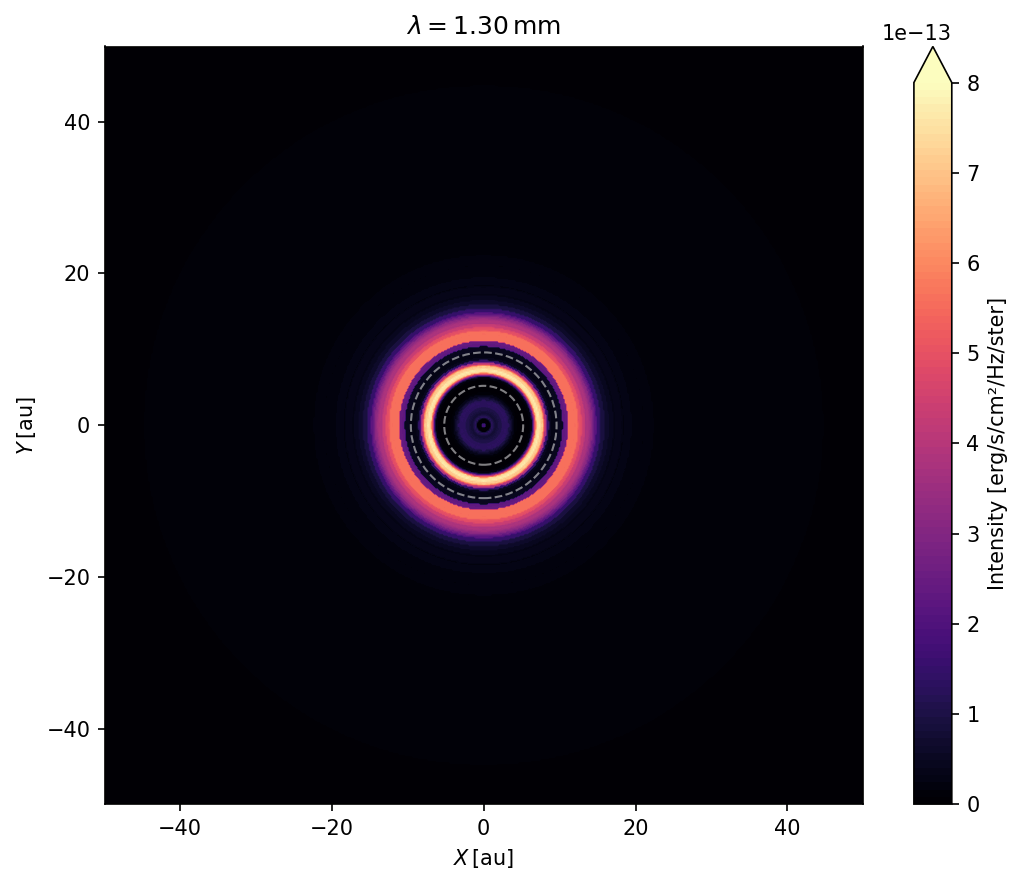

In [28]:
width, height = 7.5, 6.
x, y = image["x"]/c.au, image["y"]/c.au
Imax = image["I"].max()
mag = np.floor(np.log10(Imax))
logmax = np.ceil(Imax * 10**(-mag))
levels = np.linspace(0., logmax, 100) * 10**mag
ticks = np.arange(int(logmax)+1) * 10**mag
fig, ax = plt.subplots(figsize=(width, height))
ax.set_aspect(1)
plot = ax.contourf(x, y, image["I"][..., 0].T, cmap="magma", levels=levels, extend="max")
for name, planet in data.planets:
    circ = plt.Circle((0., 0.), radius=planet.a/c.au, fill=False, edgecolor="white", ls="--", lw=1, alpha=0.5)
    ax.add_patch(circ)
ax.set(
    aspect=1.,
    title=r"$\lambda = {:.2f}\,\mathrm{{mm}}$".format(image["lambda"][0]*10.),
    xlabel=r"$X\,\left[\mathrm{au}\right]$", ylabel=r"$Y\,\left[\mathrm{au}\right]$"
)
cbar = plt.colorbar(plot)
cbar.set_ticks(ticks)
cbar.set_label(r"Intensity [erg/s/cm²/Hz/ster]")
fig.set_layout_engine("tight")

## Slab model

DustPyLib also comes with a simple slab model to compute the intensities.

In [29]:
from dustpylib.radtrans import slab

The slab model only needs at least the data, an opacity model, and the wavelength.

In [30]:
observables = slab.get_all_observables(data, slab.Opacity("default_opacities_smooth.npz"), 0.13)

We can now compare the result of the slab model with RADMC-3D. For this we compute a azimuthally average of the RADMC-3D image to reduce the Monte Carlo noise

In [31]:
from scipy.stats import binned_statistic

In [32]:
X, Y = image["x"], image["y"]
R = np.sqrt(X[:, None]**2 + Y[None, :]**2)
ri_bins = np.geomspace(np.abs(R).min(), R.max(), 101)
r_bins = 0.5 * (ri_bins[1:] + ri_bins[:-1])
profile = binned_statistic(R.ravel(), image['I'][...,0].ravel(), bins=ri_bins).statistic

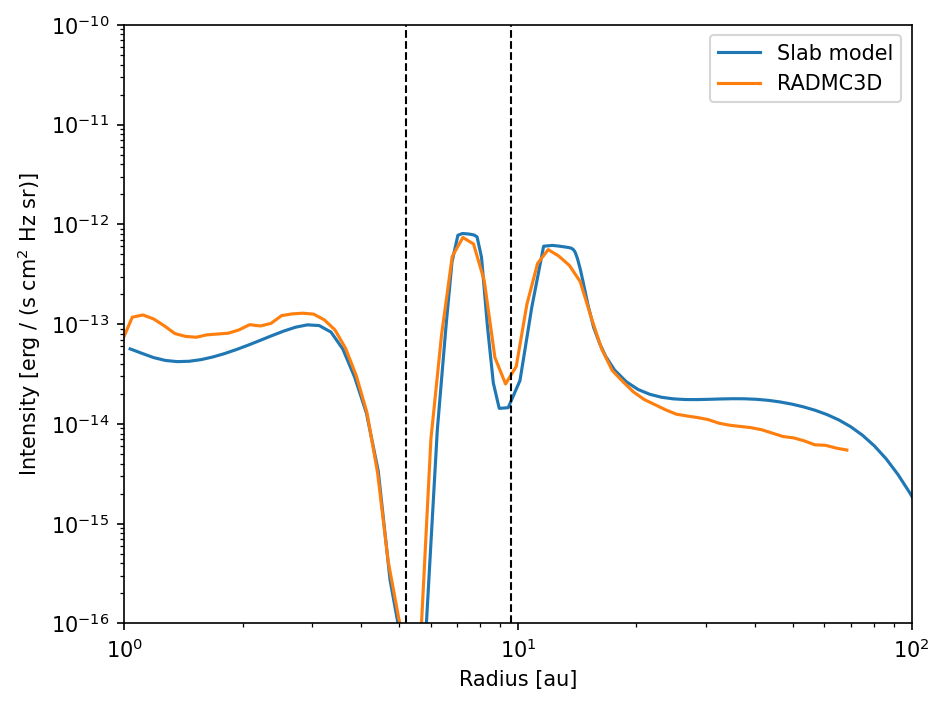

In [33]:
fig, ax = plt.subplots()
ax.loglog(data.grid.r/c.au, observables.I_nu[0, :] * slab.slab.jy_sas, label="Slab model")
ax.loglog(r_bins / c.au, profile, label="RADMC3D")
for name, planet in data.planets:
    ax.axvline(planet.a/c.au, ls="--", lw=1, color="black")
ax.legend()
ax.set(
    xlim=[1, 100], ylim=[1.e-16, 1.e-10],
    xlabel="Radius [au]", ylabel="Intensity [erg / (s cm$^2$ Hz sr)]",
)
fig.set_layout_engine("tight")